# imports

In [11]:
from cat_state import *
from state_prep_variational import *
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/Users/prathunarasimhan/Documents/cat state prep/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# example target state

In [12]:
alpha = 1.5
N = 9 # truncate to N Fock levels
cat_odd = cat_state(alpha, N, "odd")
cat_even = cat_state(alpha, N, "even")

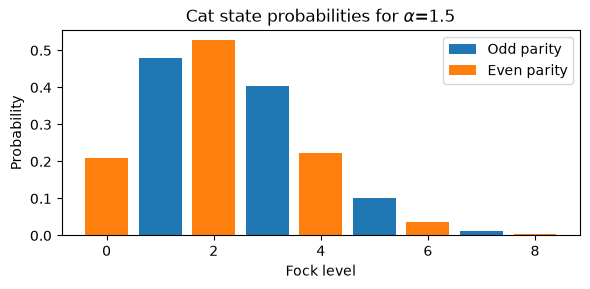

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
colors = ['tab:blue', 'tab:orange']

for i, cat in enumerate([cat_odd, cat_even]):
    probabilities = np.abs(cat)**2
    ax.bar(range(N), probabilities, color=colors[i], label=f"{'Odd' if i == 0 else 'Even'} parity")
    ax.set_title(rf"Cat state probabilities for $\alpha$={alpha}")
    ax.set_xlabel("Fock level")
    ax.set_ylabel("Probability")
    ax.legend()
plt.tight_layout()

# ansatz circuit

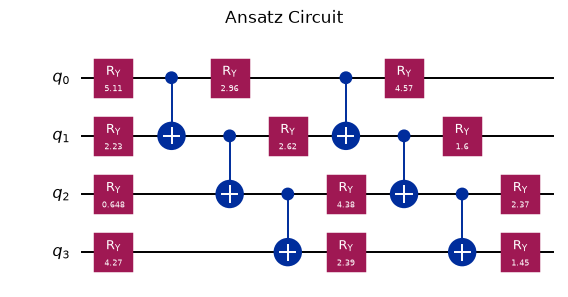

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
N_qubits = num_qubits(N)
ansatz = make_ansatz(num_qubits=N_qubits, reps=2)
theta = np.random.uniform(0, 2*np.pi, ansatz.num_parameters) # random initial angles
circuit = ansatz.assign_parameters(theta)
circuit.draw(output='mpl', ax=ax)
ax.set_title("Ansatz Circuit")
plt.tight_layout()

In [15]:
# embed cat states in qubit hilbert space
cat_odd_embedded = embed_state(cat_odd, N_qubits)
cat_even_embedded = embed_state(cat_even, N_qubits)

# optimization

In [16]:
optimized_circuit_even, optimized_state_even, history_even = optimize_circuit(ansatz, theta, target_state=cat_even_embedded, maxiter=100)
print("Optimizing for even cat state:")
print(f"{len(history_even)} iterations")
print(f"Initial fidelity: {history_even[0]}")
print(f"Final fidelity: {history_even[-1]}")

Optimizing for even cat state:
59 iterations
Initial fidelity: 0.07661308215751028
Final fidelity: 0.9724693518154567


In [17]:
optimized_circuit_odd, optimized_state_odd, history_odd = optimize_circuit(ansatz, theta, target_state=cat_odd_embedded, maxiter=100)
print("Optimizing for odd cat state:")
print(f"{len(history_odd)} iterations")
print(f"Initial fidelity: {history_odd[0]}")
print(f"Final fidelity: {history_odd[-1]}")

Optimizing for odd cat state:
61 iterations
Initial fidelity: 0.30386575233444857
Final fidelity: 0.9990382533407763


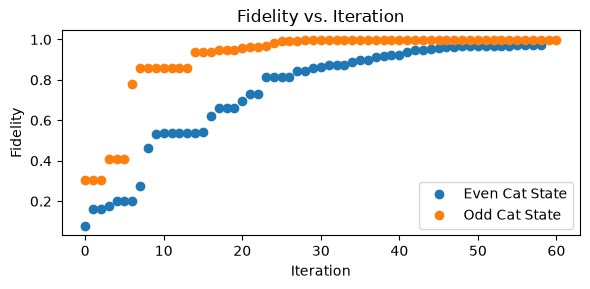

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(np.array(history_even), marker='o', linestyle='', color='tab:blue', label='Even Cat State')
ax.plot(np.array(history_odd), marker='o', linestyle='', color='tab:orange', label='Odd Cat State')

ax.set_title("Fidelity vs. Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Fidelity")
ax.legend()
plt.tight_layout()

# fidelity vs truncation level

In [27]:
alpha = 1.5
Ns = np.arange(6, 32, 2)
parity = 'even'
N_trials = 100
maxiter = 500

final_fidelities = []
for N in tqdm(Ns, desc='Truncation N'):
    cat = cat_state(alpha, N, parity)

    N_qubits = num_qubits(N)
    cat_embedded = embed_state(cat, N_qubits)
    ansatz = make_ansatz(num_qubits=N_qubits, reps=2)

    final_fidelities_trial = []
    for trial in tqdm(range(N_trials), desc=f'Trials (N={N})', leave=True):
        theta = np.random.uniform(0, 2*np.pi, ansatz.num_parameters) 
        optimized_circuit, optimized_state, history = optimize_circuit(ansatz, theta, target_state=cat_embedded, maxiter=maxiter)
        final_fidelity = history[-1]
        final_fidelities_trial.append(final_fidelity)
    final_fidelities.append(final_fidelities_trial)
final_fidelities = np.array(final_fidelities)
final_fidelities_means = np.mean(final_fidelities, axis=1)
final_fidelities_stds = np.std(final_fidelities, axis=1)

Truncation N: 100%|██████████| 13/13 [07:51<00:00, 36.27s/it]


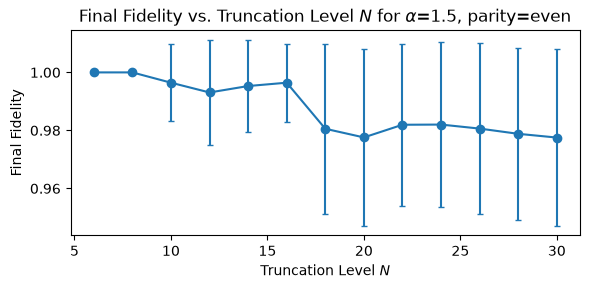

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.errorbar(Ns, final_fidelities_means, yerr=final_fidelities_stds, marker='o', linestyle='-', capsize=2, color='tab:blue')
ax.set_title(rf"Final Fidelity vs. Truncation Level $N$ for $\alpha$={alpha}, parity={parity}")
ax.set_xlabel("Truncation Level $N$")
ax.set_ylabel("Final Fidelity")
plt.tight_layout()